# Data Reading and Initial Setup

In [23]:
import json
import re
import nltk
from datetime import datetime, timezone
from collections import Counter
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from langdetect import detect, LangDetectException
from resources.abbreviations import ABBREVIATIONS

abbrev_pattern = re.compile(
    r'\b(' + '|'.join(re.escape(k) for k in ABBREVIATIONS.keys()) + r')\b'
)
stop_words = set(stopwords.words('english'))

def load_comments(filepath):
    """Load English comments from a YouTube JSON file."""
    comments = []
    skipped_non_english = 0
    skipped_empty = 0

    with open(filepath) as f:
        data = json.load(f)

    for video in data["videos"]:
        for comment in video.get("comments", []):
            text = comment.get("text", "").strip()
            if not text:
                skipped_empty += 1
                continue
            try:
                if detect(text) != 'en':
                    skipped_non_english += 1
                    continue
            except LangDetectException:
                skipped_non_english += 1
                continue

            comments.append({
                "author": comment["author"],
                "raw_text": text,
                "text": text.lower(),
                "publishedAt": comment["publishedAt"],
                "likeCount": comment["likeCount"],
                "videoTitle": video["title"],
                "channelTitle": video.get("channelTitle", ""),
            })

    print(f"{filepath}: {len(comments)} kept, {skipped_non_english} non-English, {skipped_empty} empty")
    return comments

legacy_comments = load_comments("dataCollection/data/legacy.json")
modern_comments = load_comments("dataCollection/data/modern.json")

dataCollection/data/legacy.json: 14567 kept, 2175 non-English, 2 empty
dataCollection/data/modern.json: 12518 kept, 1702 non-English, 0 empty


## Number of Unique Commenters

In [24]:
def commenter_stats(comments, label):
    authors = [c["author"] for c in comments]
    total = len(authors)
    unique = len(set(authors))
    print(f"{label}")
    print(f"  Total comments:    {total}")
    print(f"  Unique commenters: {unique}")
    return set(authors)

legacy_authors  = commenter_stats(legacy_comments,  "Legacy")
modern_authors  = commenter_stats(modern_comments,  "Modern")

all_comments = legacy_comments + modern_comments
all_authors  = legacy_authors | modern_authors
total        = len(all_comments)
unique       = len(all_authors)
print(f"Combined")
print(f"  Total comments:    {total}")
print(f"  Unique commenters: {unique}")
print(f"  Overlap (on both): {len(legacy_authors & modern_authors)}")

Legacy
  Total comments:    14567
  Unique commenters: 13212
Modern
  Total comments:    12518
  Unique commenters: 11562
Combined
  Total comments:    27085
  Unique commenters: 24373
  Overlap (on both): 401


## Timeline of comments

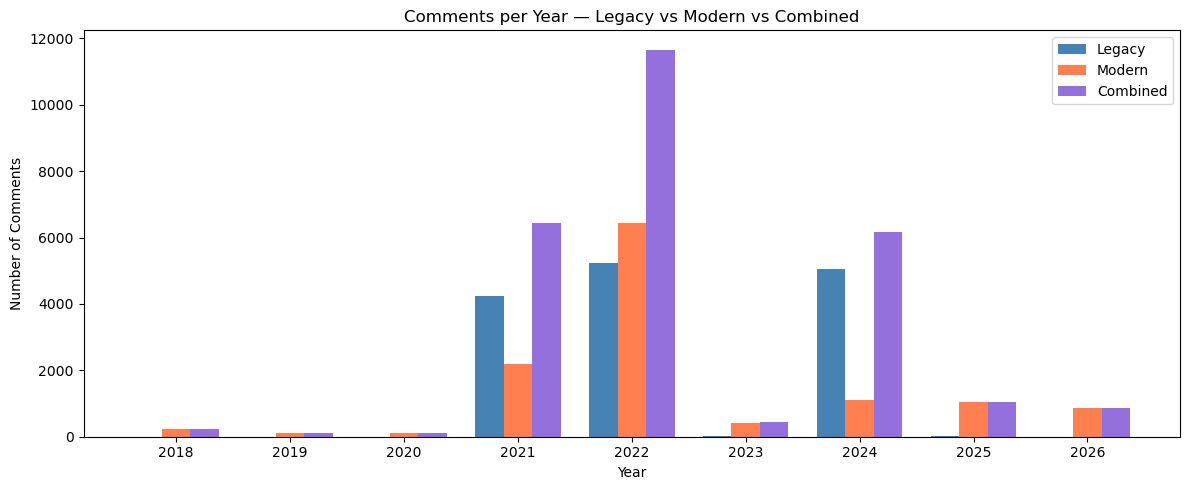

In [25]:
from collections import defaultdict
import matplotlib.pyplot as plt

def comments_by_year(comments):
    counts = defaultdict(int)
    for c in comments:
        year = datetime.fromisoformat(c["publishedAt"].replace("Z", "+00:00")).year
        counts[year] += 1
    return counts

legacy_by_year  = comments_by_year(legacy_comments)
modern_by_year  = comments_by_year(modern_comments)

all_years = sorted(set(legacy_by_year) | set(modern_by_year))

legacy_vals   = [legacy_by_year.get(y, 0)  for y in all_years]
modern_vals   = [modern_by_year.get(y, 0)  for y in all_years]
combined_vals = [l + m for l, m in zip(legacy_vals, modern_vals)]

x = range(len(all_years))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width for i in x], legacy_vals,   width=width, label="Legacy",   color="steelblue")
ax.bar([i          for i in x], modern_vals,   width=width, label="Modern",   color="coral")
ax.bar([i + width  for i in x], combined_vals, width=width, label="Combined", color="mediumpurple")

ax.set_xticks(list(x))
ax.set_xticklabels(all_years)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Comments")
ax.set_title("Comments per Year — Legacy vs Modern vs Combined")
ax.legend()
plt.tight_layout()
plt.show()

### Counting Top 50 Words Before Preprocessing

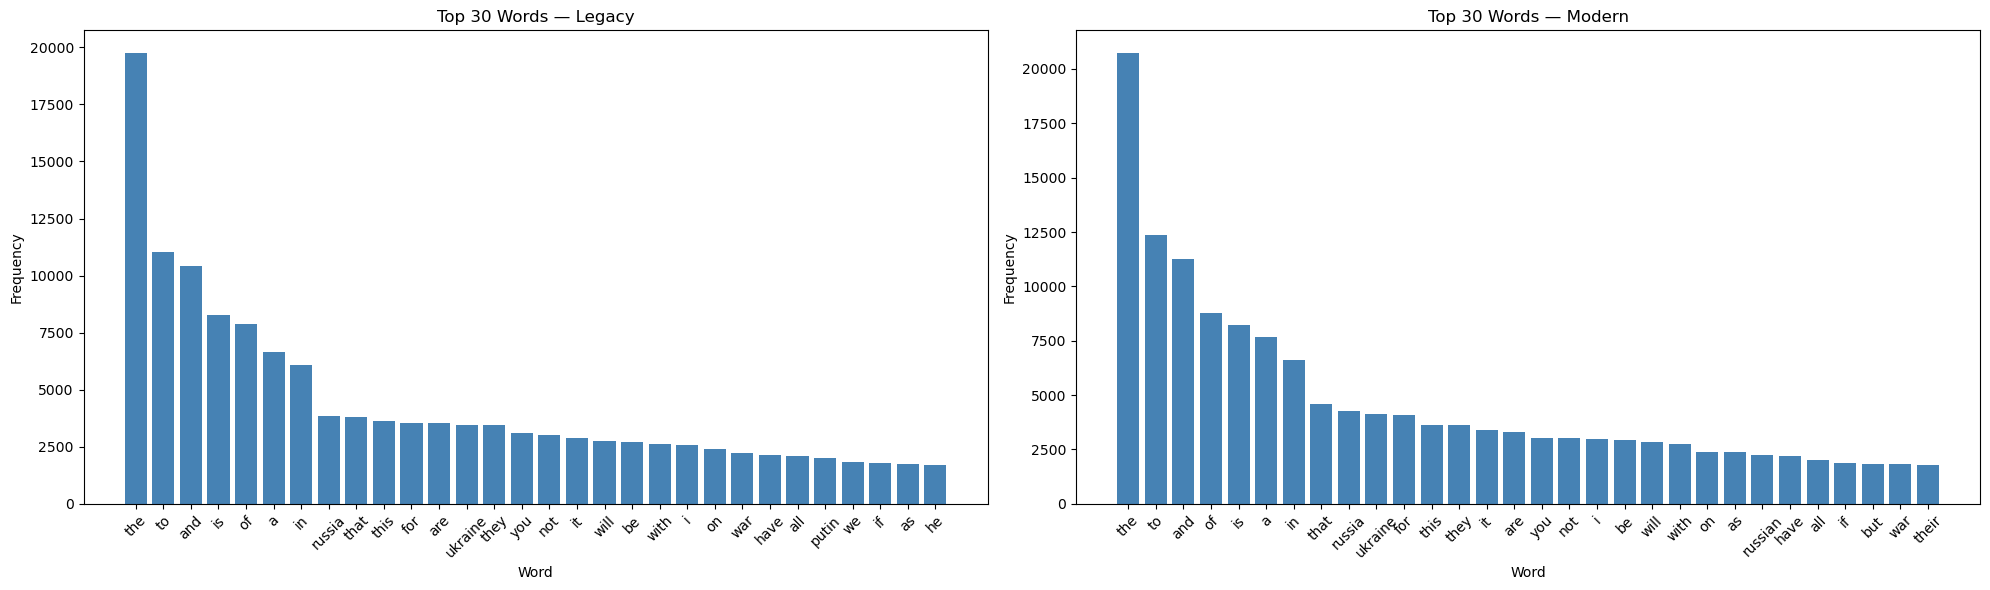

In [26]:
def plot_top_words(comments, label, ax, n=30):
    tokens = []
    for c in comments:
        tokens.extend(c["text"].split())
    top_n = Counter(tokens).most_common(n)
    words, counts = zip(*top_n)
    ax.bar(words, counts, color="steelblue")
    ax.set_title(f"Top {n} Words — {label}")
    ax.set_xlabel("Word")
    ax.set_ylabel("Frequency")
    ax.tick_params(axis="x", rotation=45)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
plot_top_words(legacy_comments,  "Legacy", ax1)
plot_top_words(modern_comments, "Modern", ax2)
plt.tight_layout()
plt.show()

# Preprocessing
Preprocessing steps below include:
- Conversion to lowercase
- URL removal
- Abbreviations and acronyms replaced with natural language words
- Digits and fractions removed
- Tokenization into individual words
- Non-alphabetic tokens (punctuation, symbols) removed
- Stop words removed

In [27]:
def _preprocess_text(text):
    text = re.sub(r"https?://\S+", "", text)          # strip URLs
    text = abbrev_pattern.sub(lambda m: ABBREVIATIONS[m.group(0)], text)
    text = re.sub(r"\b\d+([./]\d+)?\b", "", text)
    tokens = nltk.word_tokenize(text)
    tokens = [t.strip() for t in tokens if t.strip().isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    return tokens


def preprocess_comments(comments):
    """Tokenize and clean comments in-place; prints a summary."""
    for c in comments:
        c["tokens"] = _preprocess_text(c["text"])
        c["text"] = " ".join(c["tokens"])
    print(f"Preprocessed {len(comments)} comments")

preprocess_comments(legacy_comments)
preprocess_comments(modern_comments)

Preprocessed 14567 comments
Preprocessed 12518 comments


### Counting Top 50 Words After Preprocessing

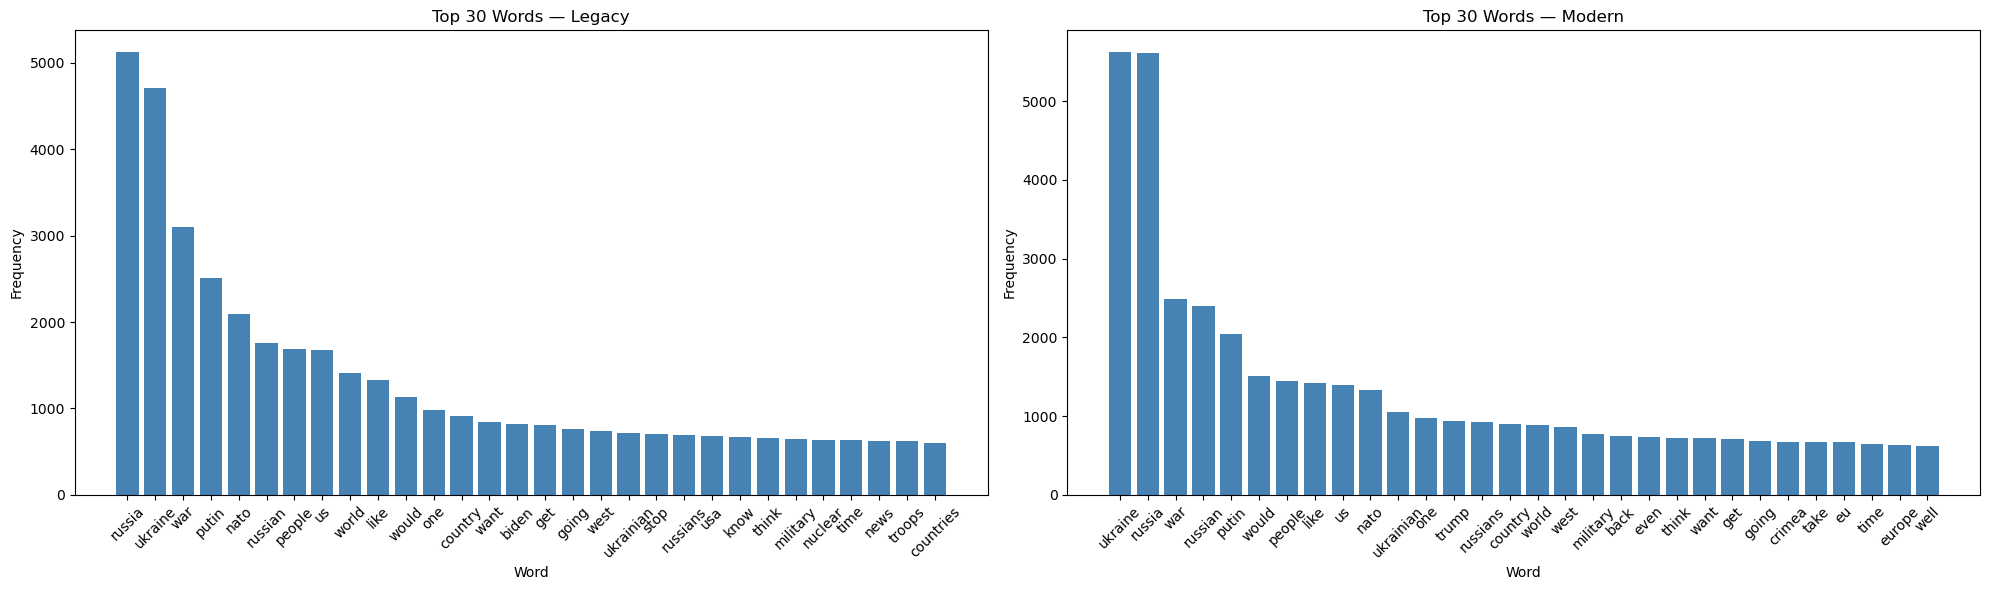

In [28]:
def plot_top_words(comments, label, ax, n=30):
    tokens = []
    for c in comments:
        tokens.extend(c["text"].split())
    top_n = Counter(tokens).most_common(n)
    words, counts = zip(*top_n)
    ax.bar(words, counts, color="steelblue")
    ax.set_title(f"Top {n} Words — {label}")
    ax.set_xlabel("Word")
    ax.set_ylabel("Frequency")
    ax.tick_params(axis="x", rotation=45)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
plot_top_words(legacy_comments,  "Legacy", ax1)
plot_top_words(modern_comments, "Modern", ax2)
plt.tight_layout()
plt.show()

# Sentiment Analysis

In [29]:
def run_sentiment(comments):
    sia = SentimentIntensityAnalyzer()
    vader_labels = Counter()

    for c in comments:
        scores = sia.polarity_scores(c["raw_text"])
        c["vaderScores"] = scores
        c["vaderCompound"] = scores["compound"]
        if scores["compound"] >= 0.05:
            c["vaderLabel"] = "positive"
        elif scores["compound"] <= -0.05:
            c["vaderLabel"] = "negative"
        else:
            c["vaderLabel"] = "neutral"
        vader_labels[c["vaderLabel"]] += 1

    total = len(comments)
    return {
        "total": total,
        "vader": {k: {"n": v, "pct": v / total * 100} for k, v in vader_labels.items()},
        "vader_mean": sum(c["vaderCompound"] for c in comments) / total,
    }

legacy_summary = run_sentiment(legacy_comments)
modern_summary = run_sentiment(modern_comments)

# Sentiment Analysis Summaries

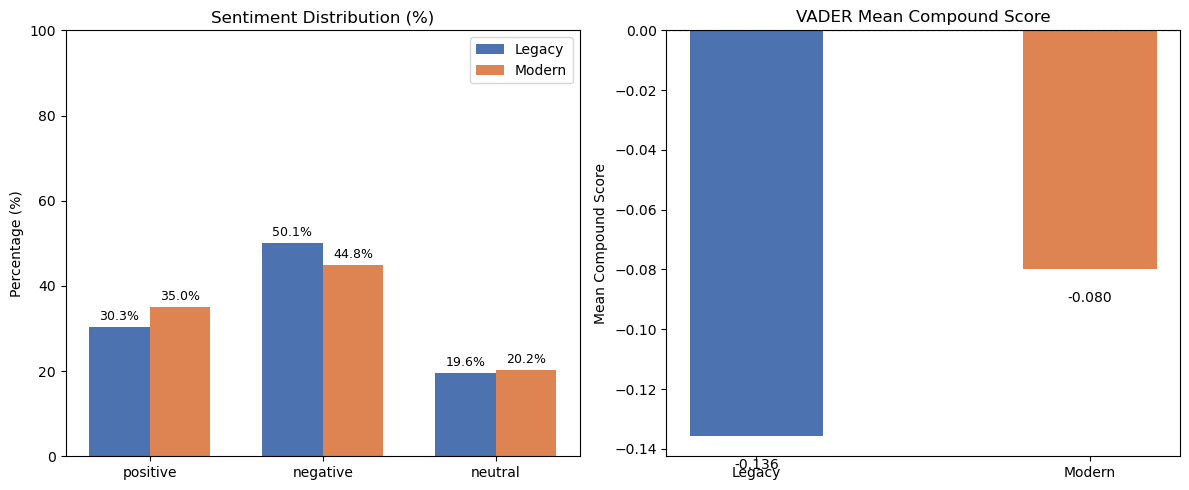

In [36]:
import numpy as np

def compare_summaries(legacy_summary, modern_summary):
    cats = ["positive", "negative", "neutral"]
    x = np.arange(len(cats))
    width = 0.35

    legacy_pcts  = [legacy_summary["vader"].get(c, {"pct": 0.0})["pct"]  for c in cats]
    modern_pcts  = [modern_summary["vader"].get(c, {"pct": 0.0})["pct"]  for c in cats]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Sentiment distribution
    bars_l = axes[0].bar(x - width/2, legacy_pcts, width, label="Legacy", color="#4C72B0")
    bars_m = axes[0].bar(x + width/2, modern_pcts, width, label="Modern", color="#DD8452")
    axes[0].set_title("Sentiment Distribution (%)")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(cats)
    axes[0].set_ylabel("Percentage (%)")
    axes[0].set_ylim(0, 100)
    axes[0].legend()
    for bar in [*bars_l, *bars_m]:
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                     f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)

    # VADER mean compound score
    means  = [legacy_summary["vader_mean"], modern_summary["vader_mean"]]
    colors = ["#4C72B0", "#DD8452"]
    bars   = axes[1].bar(["Legacy", "Modern"], means, color=colors, width=0.4)
    axes[1].set_title("VADER Mean Compound Score")
    axes[1].set_ylabel("Mean Compound Score")
    axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    for bar, val in zip(bars, means):
        offset = 0.005 if val >= 0 else -0.012
        axes[1].text(bar.get_x() + bar.get_width() / 2, val + offset,
                     f"{val:.3f}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()

compare_summaries(legacy_summary, modern_summary)

# Word Clouds

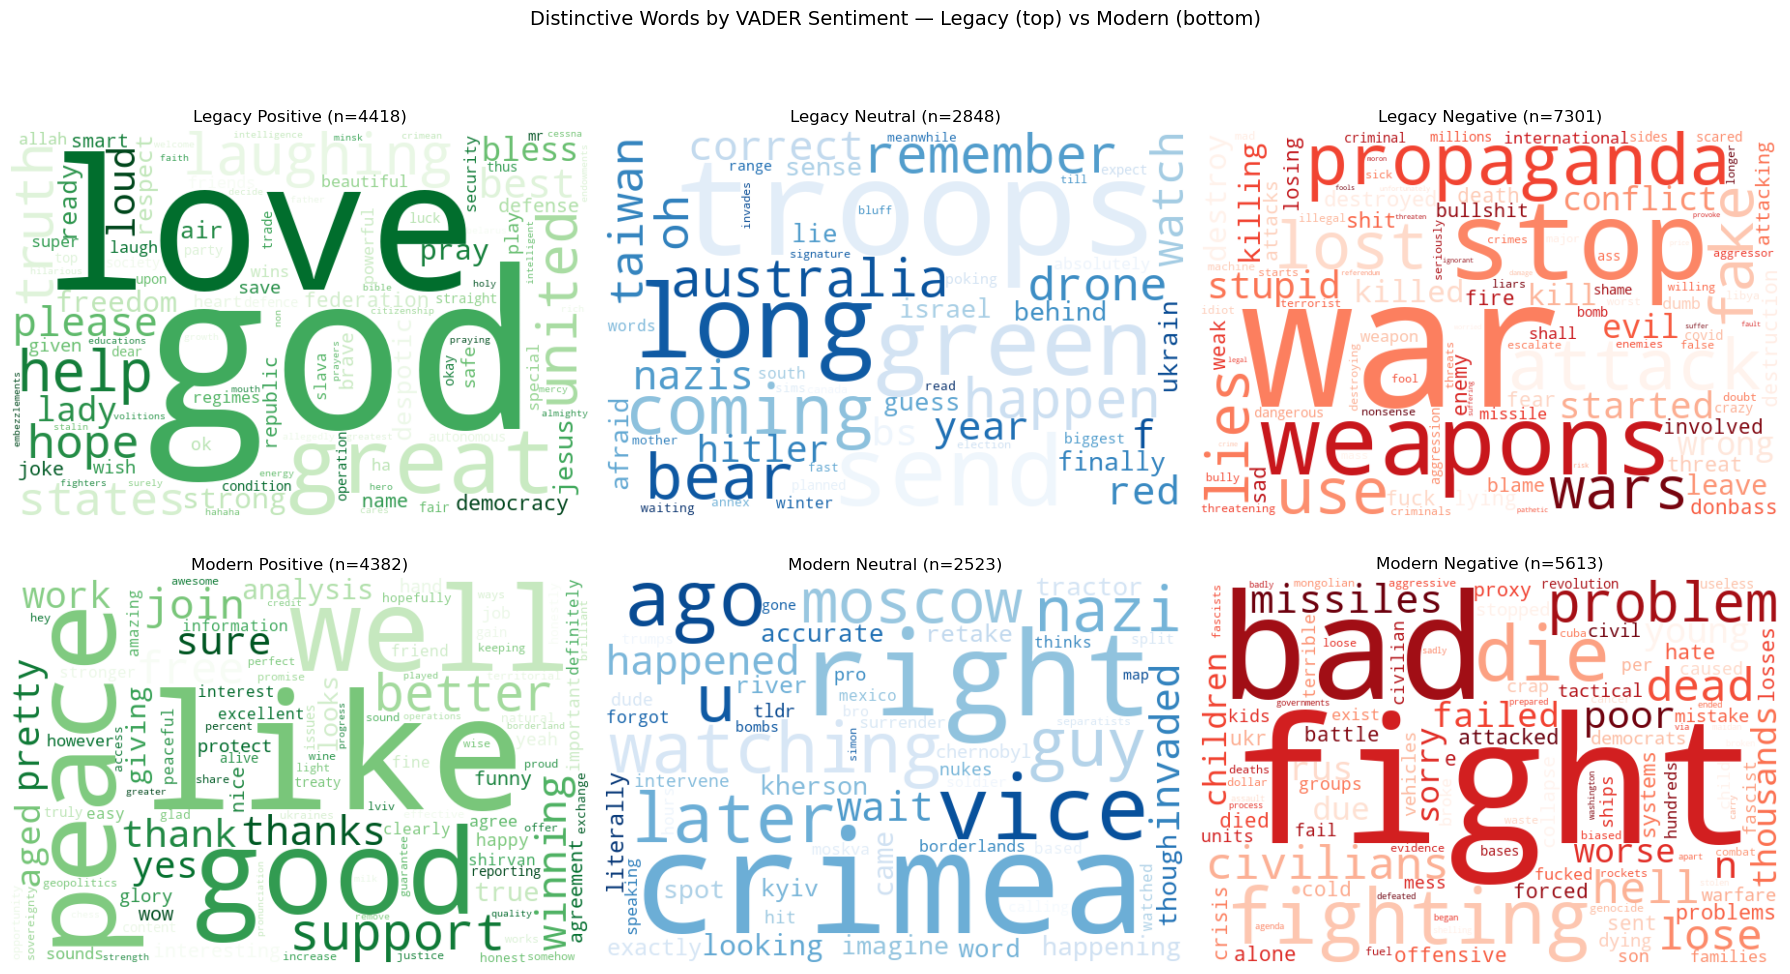

In [33]:
from wordcloud import WordCloud

def get_distinctive(comments_subset, all_comments, min_count=10):
    subset_ids = set(map(id, comments_subset))
    subset_freq = Counter(t for c in comments_subset for t in c['tokens'])
    rest_freq   = Counter(t for c in all_comments if id(c) not in subset_ids
                          for t in c['tokens'])
    total_sub  = sum(subset_freq.values()) or 1
    total_rest = sum(rest_freq.values()) or 1
    return {
        w: subset_freq[w]
        for w in subset_freq
        if subset_freq[w] >= min_count
        and subset_freq[w] / total_sub > 2 * (rest_freq.get(w, 0) / total_rest)
    }

def deduplicate_groups(freq_groups):
    result = {label: dict(freq) for label, freq in freq_groups.items()}
    for word in set(w for f in freq_groups.values() for w in f):
        best = max(freq_groups, key=lambda l: freq_groups[l].get(word, 0))
        for label in result:
            if label != best:
                result[label].pop(word, None)
    return result

# Legacy splits
l_pos = [c for c in legacy_comments if c['vaderCompound'] >= 0.05]
l_neu = [c for c in legacy_comments if -0.05 < c['vaderCompound'] < 0.05]
l_neg = [c for c in legacy_comments if c['vaderCompound'] <= -0.05]

# Modern splits
m_pos = [c for c in modern_comments if c['vaderCompound'] >= 0.05]
m_neu = [c for c in modern_comments if -0.05 < c['vaderCompound'] < 0.05]
m_neg = [c for c in modern_comments if c['vaderCompound'] <= -0.05]

groups = [
    (l_pos, legacy_comments, f'Legacy Positive (n={len(l_pos)})', 'Greens'),
    (l_neu, legacy_comments, f'Legacy Neutral (n={len(l_neu)})',  'Blues'),
    (l_neg, legacy_comments, f'Legacy Negative (n={len(l_neg)})', 'Reds'),
    (m_pos, modern_comments, f'Modern Positive (n={len(m_pos)})', 'Greens'),
    (m_neu, modern_comments, f'Modern Neutral (n={len(m_neu)})',  'Blues'),
    (m_neg, modern_comments, f'Modern Negative (n={len(m_neg)})', 'Reds'),
]

raw_freqs = {title: get_distinctive(subset, all_c) for subset, all_c, title, cmap in groups}
deduped   = deduplicate_groups(raw_freqs)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (subset, all_c, title, cmap) in zip(axes.flat, groups):
    freq = deduped[title]
    if freq:
        wc = WordCloud(width=600, height=400, background_color='white',
                       colormap=cmap, max_words=100)
        wc.generate_from_frequencies(freq)
        ax.imshow(wc, interpolation='bilinear')
    else:
        ax.text(0.5, 0.5, 'Not enough\ndistinctive words',
                ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')
    ax.set_title(title, fontsize=12)

plt.suptitle('Distinctive Words by VADER Sentiment — Legacy (top) vs Modern (bottom)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Sentiment Over Time

/var/folders/rj/rphv43m50hv9vdbh5ycwlkyc0000gn/T/ipykernel_1972/1829155626.py:23: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined = pd.concat([legacy_monthly, modern_monthly], axis=1).sort_index()


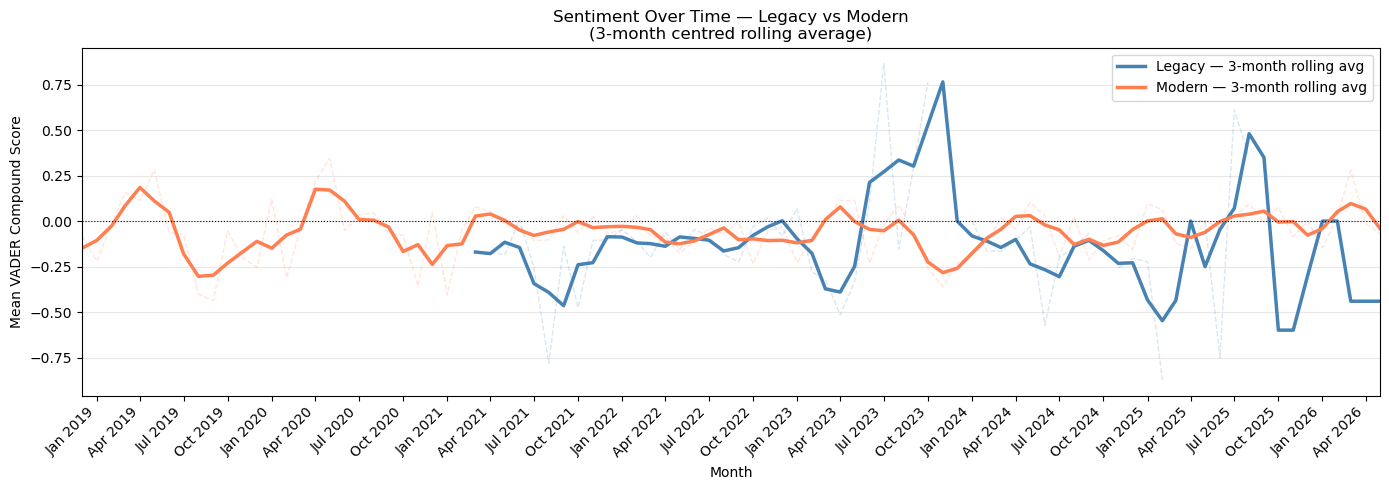

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Build monthly mean VADER compound score ---
def monthly_sentiment(comments, label):
    rows = [
        {
            "month": datetime.fromisoformat(c["publishedAt"].replace("Z", "+00:00"))
                             .replace(day=1, hour=0, minute=0, second=0, microsecond=0,
                                      tzinfo=None),
            "compound": c["vaderCompound"],
        }
        for c in comments
    ]
    df = pd.DataFrame(rows)
    return df.groupby("month")["compound"].mean().rename(label)

legacy_monthly = monthly_sentiment(legacy_comments, "Legacy")
modern_monthly = monthly_sentiment(modern_comments, "Modern")

# Align on the same date index, compute 3-month centred rolling average
combined = pd.concat([legacy_monthly, modern_monthly], axis=1).sort_index()
rolling  = combined.rolling(window=3, min_periods=1, center=True).mean()


fig, ax = plt.subplots(figsize=(14, 5))

# Rolling averages (bold)
ax.plot(rolling.index, rolling["Legacy"], color="steelblue", linewidth=2.5, label="Legacy — 3-month rolling avg")
ax.plot(rolling.index, rolling["Modern"], color="coral",     linewidth=2.5, label="Modern — 3-month rolling avg")

# Raw monthly means (faint, for context)
ax.plot(combined.index, combined["Legacy"], color="steelblue", alpha=0.2, linewidth=1, linestyle="--")
ax.plot(combined.index, combined["Modern"], color="coral",     alpha=0.2, linewidth=1, linestyle="--")

# Neutral baseline
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")

ax.set_xlim(combined.index.min(), combined.index.max())
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")

ax.set_xlabel("Month")
ax.set_ylabel("Mean VADER Compound Score")
ax.set_title("Sentiment Over Time — Legacy vs Modern\n(3-month centred rolling average)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── LDA Topic Modeling: Legacy vs Modern Corpus ──────────────────────────────
import json, re, warnings
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

warnings.filterwarnings("ignore")

# ── 1. Load corpora ──────────────────────────────────────────────────────────
with open("dataCollection/data/legacy.json") as f:
    legacy_data = json.load(f)
with open("dataCollection/data/modern.json") as f:
    modern_data = json.load(f)

def extract_comments(data):
    return [
        c["text"]
        for v in data["videos"]
        for c in v.get("comments", [])
        if isinstance(c.get("text"), str)
    ]

legacy_docs = extract_comments(legacy_data)
modern_docs = extract_comments(modern_data)
print(f"Legacy corpus: {len(legacy_docs)} comments")
print(f"Modern corpus: {len(modern_docs)} comments")

# ── 2. Preprocessing ─────────────────────────────────────────────────────────
URL_RE = re.compile(r"http\S+|www\.\S+")

def clean(text):
    text = URL_RE.sub("", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    return text.lower().strip()

legacy_clean  = [clean(t) for t in legacy_docs]
modern_clean  = [clean(t) for t in modern_docs]

# ── 3. Fit LDA with sklearn CountVectorizer ──────────────────────────────────
GEOPOLITICAL_STOPWORDS = [
    # generic English stopwords are handled by sklearn; add domain noise below
    "video", "watch", "channel", "subscribe", "like", "comment",
    "please", "thank", "thanks", "just", "know", "think", "people",
    "time", "good", "make", "going", "want", "said", "say", "come",
    "got", "get", "let", "go", "us", "one", "would", "could", "also",
    "don", "didn", "isn", "aren", "won", "doesn", "ll", "ve", "re",
    "ukraine", "russia", "ukrainian", "russian",   # too dominant everywhere
]

def make_vectorizer():
    return CountVectorizer(
        stop_words="english",
        max_df=0.90,          # drop words in >90% of docs (noise)
        min_df=10,            # need at least 10 occurrences
        max_features=5000,
        vocabulary=None,
    )

def fit_lda(docs, n_topics=6, n_top_words=12, label=""):
    vec = make_vectorizer()
    dtm = vec.fit_transform(docs)
    
    # remove domain-noise tokens post-hoc
    feature_names = np.array(vec.get_feature_names_out())
    keep = np.array([w not in GEOPOLITICAL_STOPWORDS for w in feature_names])
    dtm  = dtm[:, keep]
    feature_names = feature_names[keep]

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        max_iter=20,
        learning_method="online",
        random_state=42,
        n_jobs=-1,
    )
    lda.fit(dtm)

    print(f"\n{'='*60}")
    print(f"  {label} — {n_topics} Topics")
    print(f"{'='*60}")
    rows = []
    for i, topic_vec in enumerate(lda.components_):
        top_idx   = topic_vec.argsort()[-n_top_words:][::-1]
        top_words = feature_names[top_idx]
        print(f"\n  Topic {i+1}: {' | '.join(top_words)}")
        rows.append({"topic": f"T{i+1}", "top_words": ", ".join(top_words)})
    return pd.DataFrame(rows), lda, vec

legacy_df, legacy_lda, legacy_vec = fit_lda(legacy_clean, n_topics=6, label="LEGACY (pre-2022)")
modern_df, modern_lda, modern_vec = fit_lda(modern_clean, n_topics=6, label="MODERN (2022+)")

# ── 4. Display side-by-side summary ─────────────────────────────────────────
print("\n\n" + "="*60)
print("SIDE-BY-SIDE TOPIC COMPARISON")
print("="*60)
comparison = pd.concat(
    [legacy_df.rename(columns={"top_words": "Legacy Topics"}),
     modern_df[["top_words"]].rename(columns={"top_words": "Modern Topics"})],
    axis=1
)
pd.set_option("display.max_colwidth", 80)
print(comparison.to_string(index=False))

# ── 5. Research question: geopolitics vs military/propaganda framing ─────────
print("""
──────────────────────────────────────────────────────────────────────────────
INTERPRETIVE LENS FOR YOUR PAPER
──────────────────────────────────────────────────────────────────────────────
Look for:
  LEGACY topics → institutions & geopolitics:
    keywords: nato, sanctions, eu, treaty, un, diplomacy, agreement, west,
              economy, energy, pipeline, gas, crimea, donbas, border

  MODERN topics → military events & propaganda:
    keywords: attack, missile, drone, war, troops, army, front, zelensky,
              propaganda, fake, media, truth, soldier, battle, strike

If legacy clusters around the first set and modern around the second,
your paper title could be:
  "From Geopolitics to Gunfire: How Online Discourse About the
   Russia-Ukraine Conflict Shifted from Institutional Framing to
   Military Narrative (2014-2022 vs 2022-2024)"
──────────────────────────────────────────────────────────────────────────────
""")


Legacy corpus: 16744 comments
Modern corpus: 14220 comments
